# Employee Attrition Prediction Using Predictive Analytics

## Project Overview

This project aims to develop a machine learning model to predict whether an employee is likely to leave an organization based on factors such as job role, income, satisfaction, overtime, age, and years of experience.

The project applies data preprocessing, exploratory data analysis, feature engineering, classification algorithms, and model evaluation to identify patterns associated with employee attrition and build a reliable predictive model.

### Objectives

- Analyze employee data and identify factors associated with attrition.
- Explore relationships between employee characteristics and turnover.
- Prepare and transform the dataset for machine learning.
- Train and compare multiple classification models.
- Evaluate model performance using appropriate classification metrics.
- Identify the most influential factors contributing to predicted attrition.
- Develop a final model capable of predicting employee attrition for new employee records.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Environment ready!")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

Environment ready!
pandas: 3.0.6
numpy: 2.5.3
scikit-learn: 1.9.1


## 1. Dataset Loading

The dataset used in this project is the IBM HR Analytics Employee Attrition & Performance dataset. It contains employee-related information such as age, job role, income, job satisfaction, overtime, years of experience, and other workplace characteristics.

The target variable is `Attrition`, which indicates whether an employee left the organization.

In [65]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Dataset Overview

The dataset contains employee demographic, job-related, compensation, satisfaction, and performance-related attributes. The `Attrition` column serves as the target variable for the classification problem.

In [66]:
df.shape

(1470, 35)

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

## 2. Data Quality Assessment

Before performing exploratory analysis or training machine learning models, the dataset must be checked for missing values, duplicate records, and other potential data-quality issues.

In [68]:
# Check for missing values
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [69]:
# Display the number of unique values in each column
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

## 3. Target Variable Analysis

The target variable for this project is `Attrition`. It represents whether an employee left the organization.

Since classification models can be affected by an imbalanced target variable, we first examine the distribution of employees who stayed versus those who left.

In [70]:
# Count employees in each attrition category
attrition_counts = df["Attrition"].value_counts()

print(attrition_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [71]:
# Calculate attrition percentages
attrition_percentages = df["Attrition"].value_counts(normalize=True) * 100

print(attrition_percentages.round(2))

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


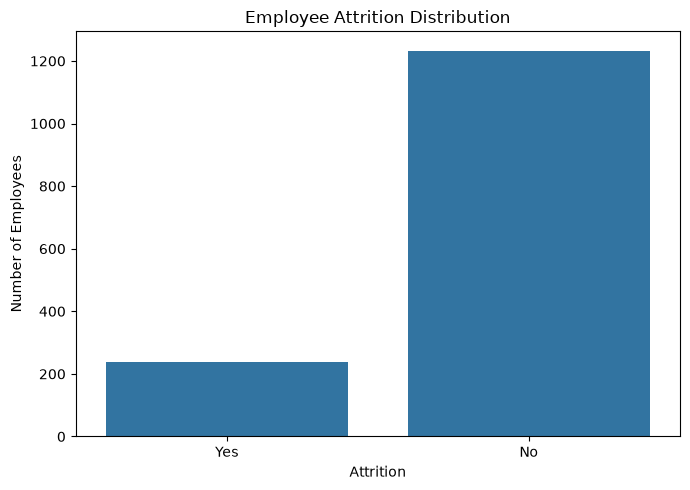

In [72]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand patterns and relationships within the dataset before applying machine learning models.

The analysis focuses on demographic, job-related, compensation, satisfaction, and work-condition factors that may be associated with employee attrition.

### 4.1 Attrition by Overtime

Overtime is examined because employees who regularly work beyond their normal hours may experience increased workload and reduced work-life balance, which could be associated with higher attrition.

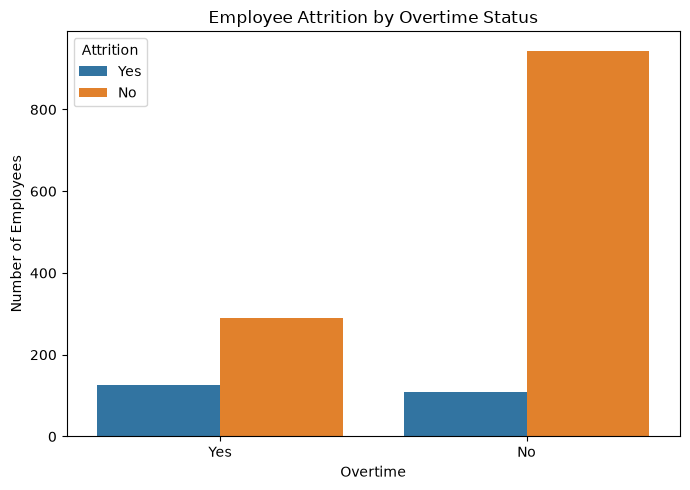

In [73]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="OverTime", hue="Attrition")

plt.title("Employee Attrition by Overtime Status")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")
plt.legend(title="Attrition")

plt.tight_layout()
plt.show()

In [74]:
overtime_attrition = (
    df.groupby("OverTime")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(overtime_attrition.round(2))

OverTime
Yes    30.53
No     10.44
Name: Attrition, dtype: float64


### 4.2 Attrition by Job Satisfaction

Job satisfaction is analyzed to determine whether employees with different levels of satisfaction show different attrition patterns.

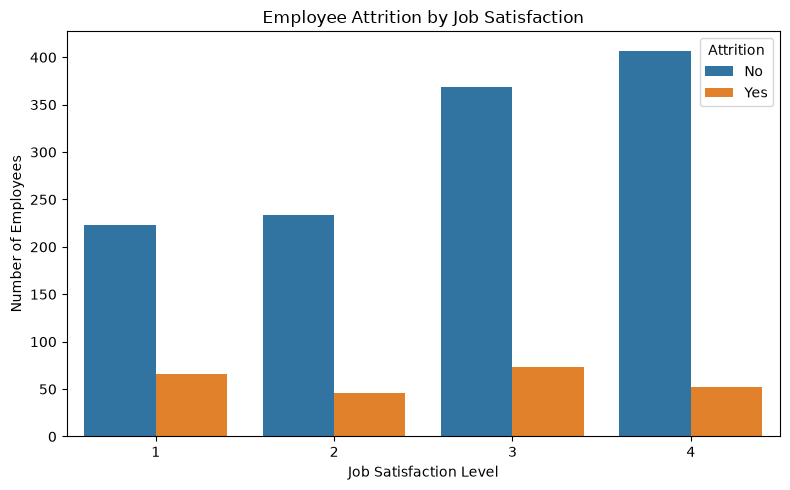

In [75]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="JobSatisfaction", hue="Attrition")

plt.title("Employee Attrition by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Number of Employees")
plt.legend(title="Attrition")

plt.tight_layout()
plt.show()

In [76]:
satisfaction_attrition = (
    df.groupby("JobSatisfaction")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(satisfaction_attrition.round(2))

JobSatisfaction
1    22.84
2    16.43
3    16.52
4    11.33
Name: Attrition, dtype: float64


### 4.3 Attrition by Age

Age is examined to determine whether attrition patterns differ across different stages of an employee's career.

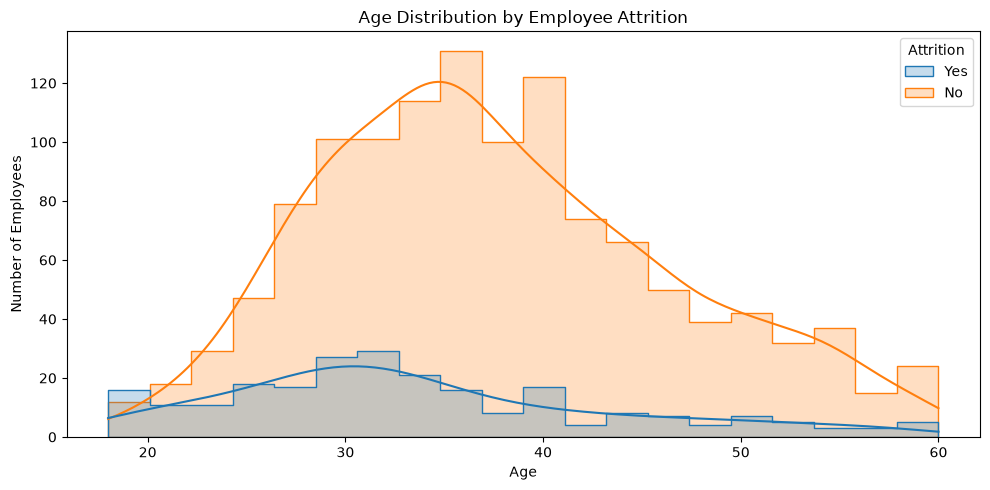

In [77]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Age",
    hue="Attrition",
    bins=20,
    kde=True,
    element="step"
)

plt.title("Age Distribution by Employee Attrition")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

In [78]:
age_groups = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=["Under 25", "25–35", "36–45", "46–55", "56+"]
)

age_attrition = (
    df.groupby(age_groups, observed=True)["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(age_attrition.round(2))

Age
Under 25    35.77
25–35       19.14
36–45        9.19
46–55       11.50
56+         17.02
Name: Attrition, dtype: float64


### 4.4 Attrition by Monthly Income

Monthly income is analyzed to investigate whether compensation levels are associated with employee attrition.

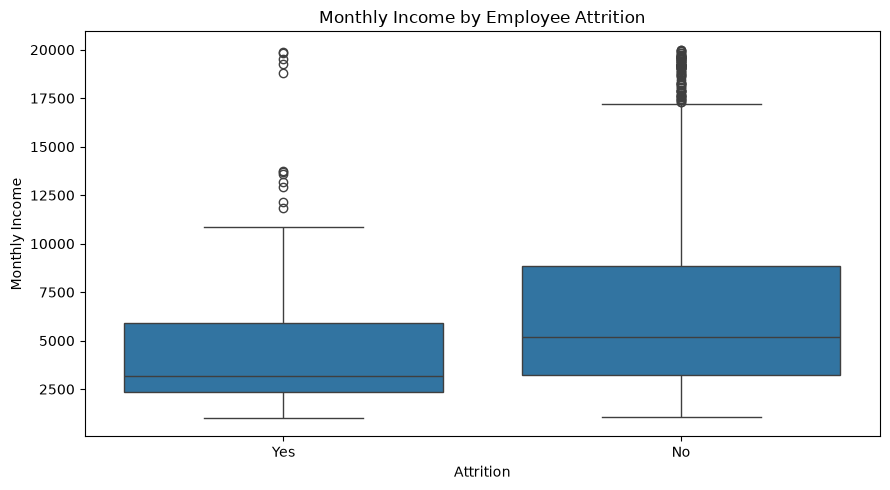

In [79]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.show()

In [80]:
income_groups = pd.qcut(
    df["MonthlyIncome"],
    q=4,
    labels=["Lowest", "Low-Mid", "High-Mid", "Highest"]
)

income_attrition = (
    df.groupby(income_groups, observed=True)["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(income_attrition.round(2))

MonthlyIncome
Lowest      29.27
Low-Mid     14.21
High-Mid    10.63
Highest     10.33
Name: Attrition, dtype: float64


### 4.5 Attrition by Job Role

Job role is analyzed to determine whether employee attrition varies across different positions within the organization.

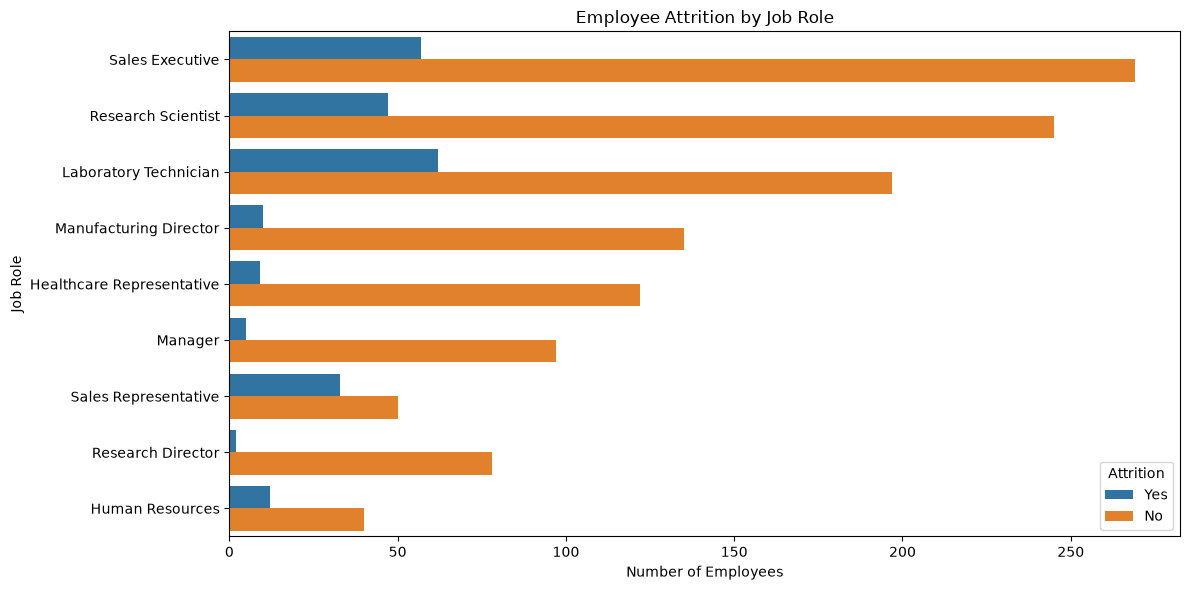

In [81]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y="JobRole",
    hue="Attrition",
    order=df["JobRole"].value_counts().index
)

plt.title("Employee Attrition by Job Role")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")
plt.legend(title="Attrition")

plt.tight_layout()
plt.show()

In [82]:
job_role_attrition = (
    df.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(job_role_attrition.round(2))

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


### 4.6 Attrition by Years at Company

The number of years an employee has worked at the company is examined to determine whether attrition patterns differ between newer and more experienced employees.

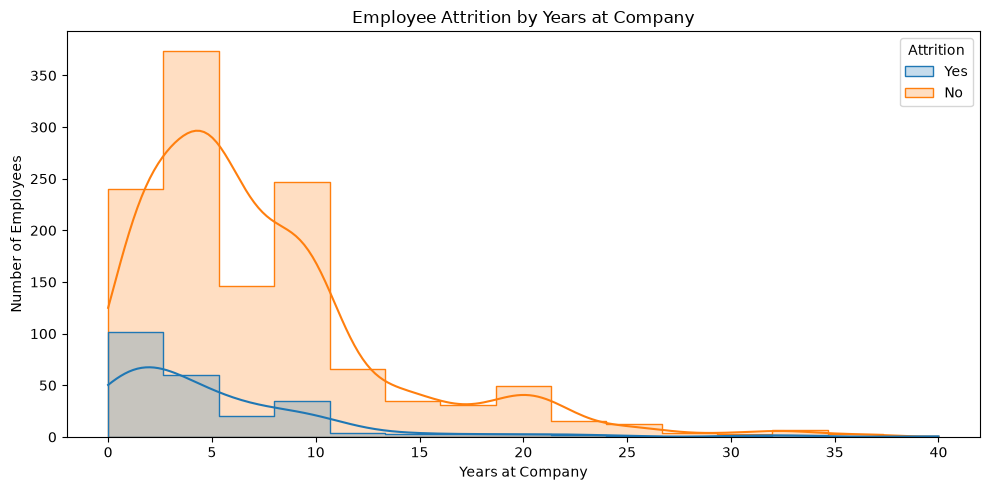

In [83]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition",
    bins=15,
    kde=True,
    element="step"
)

plt.title("Employee Attrition by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

In [84]:
tenure_groups = pd.cut(
    df["YearsAtCompany"],
    bins=[-1, 2, 5, 10, 20, float("inf")],
    labels=["0–2", "3–5", "6–10", "11–20", "21+"]
)

tenure_attrition = (
    df.groupby(tenure_groups, observed=True)["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(tenure_attrition.round(2))

YearsAtCompany
0–2      29.82
3–5      13.82
6–10     12.28
11–20     6.67
21+      12.12
Name: Attrition, dtype: float64


### 4.7 Attrition by Work-Life Balance

Work-life balance is examined to determine whether employees reporting different levels of work-life balance show different attrition patterns.

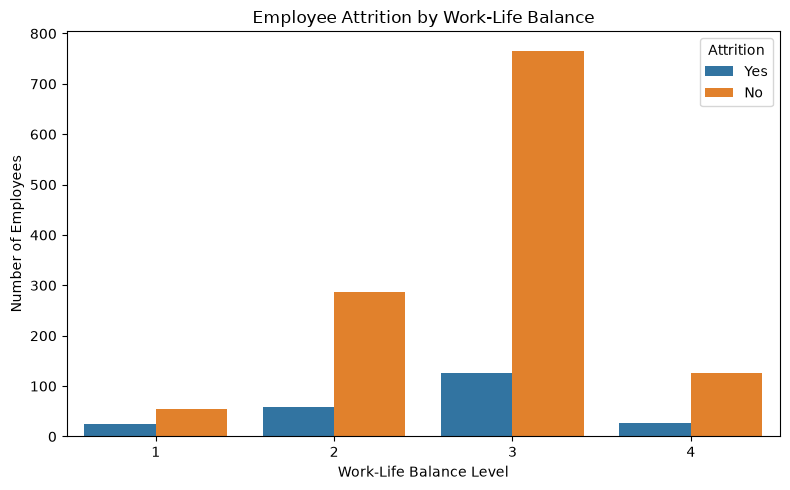

In [85]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Employee Attrition by Work-Life Balance")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Number of Employees")
plt.legend(title="Attrition")

plt.tight_layout()
plt.show()

In [86]:
worklife_attrition = (
    df.groupby("WorkLifeBalance")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_index()
)

print(worklife_attrition.round(2))

WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64


### 4.8 Attrition by Distance From Home

Distance from home is analyzed to investigate whether commuting distance may be associated with employee attrition.

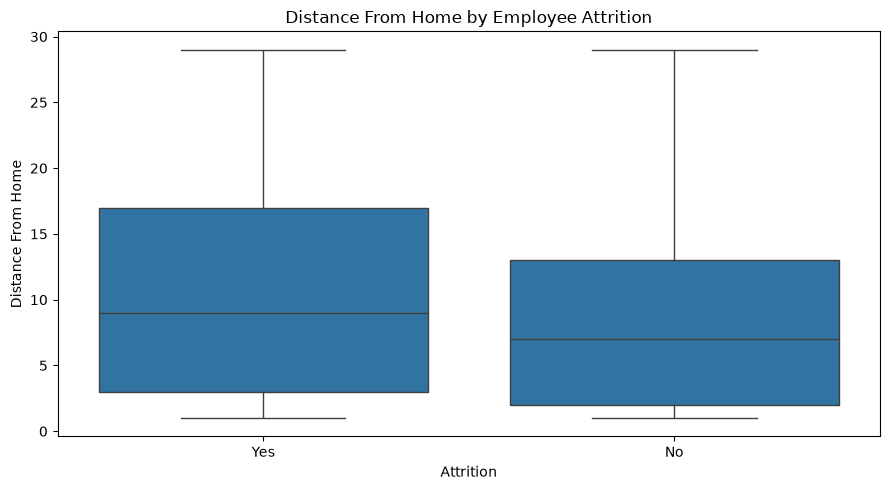

In [87]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="DistanceFromHome"
)

plt.title("Distance From Home by Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Distance From Home")

plt.tight_layout()
plt.show()

In [88]:
distance_groups = pd.cut(
    df["DistanceFromHome"],
    bins=[0, 5, 10, 20, float("inf")],
    labels=["1–5", "6–10", "11–20", "21+"]
)

distance_attrition = (
    df.groupby(distance_groups, observed=True)["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(distance_attrition.round(2))

DistanceFromHome
1–5      13.77
6–10     14.47
11–20    20.00
21+      22.06
Name: Attrition, dtype: float64


### 4.9 Attrition by Business Travel

Business travel frequency is examined to determine whether employees who travel more frequently show different attrition patterns.

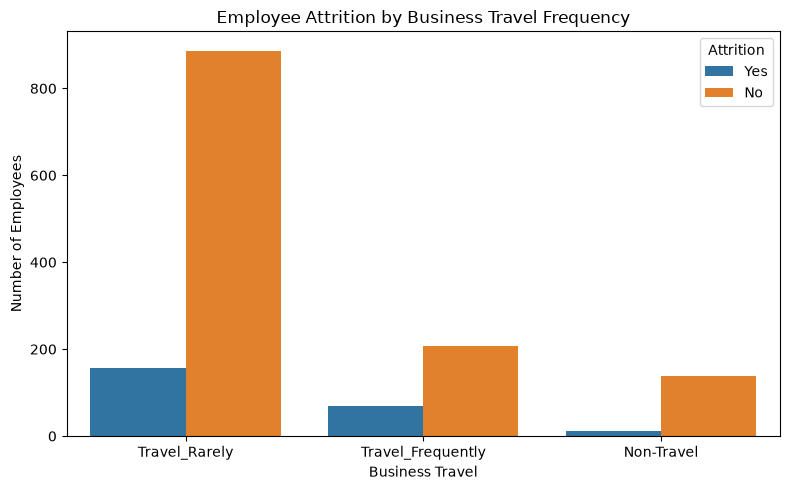

In [89]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="BusinessTravel",
    hue="Attrition"
)

plt.title("Employee Attrition by Business Travel Frequency")
plt.xlabel("Business Travel")
plt.ylabel("Number of Employees")
plt.legend(title="Attrition")

plt.tight_layout()
plt.show()

In [90]:
travel_attrition = (
    df.groupby("BusinessTravel")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(travel_attrition.round(2))

BusinessTravel
Travel_Frequently    24.91
Travel_Rarely        14.96
Non-Travel            8.00
Name: Attrition, dtype: float64


### 4.10 Attrition by Department

Department-level attrition is analyzed to determine whether employee turnover varies across major areas of the organization.

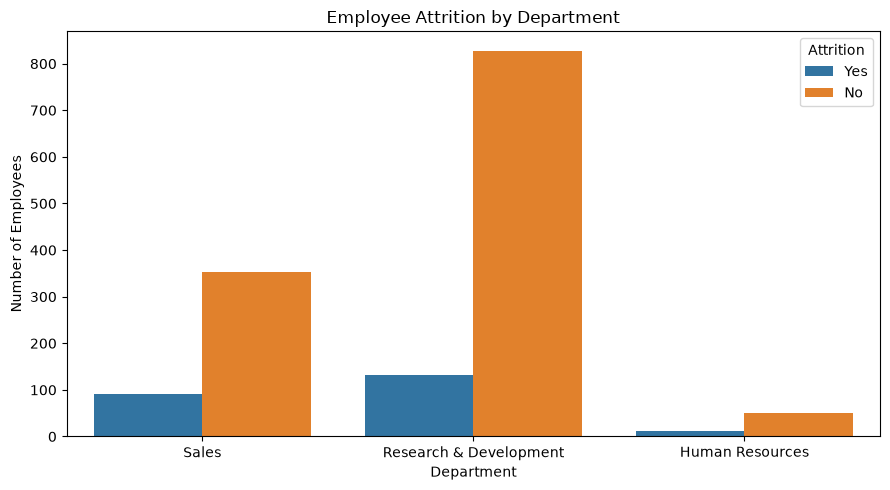

In [91]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

plt.title("Employee Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.legend(title="Attrition")

plt.tight_layout()
plt.show()

In [92]:
department_attrition = (
    df.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(department_attrition.round(2))

Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


### 4.11 Numerical Feature Relationships

Numerical variables can provide additional insight into factors associated with employee attrition. Correlation analysis is used to examine relationships between numerical features and identify variables that may be useful for predictive modeling.

In [93]:
# Convert Attrition into a binary variable for correlation analysis
df_corr = df.copy()
df_corr["Attrition_Encoded"] = df_corr["Attrition"].map({"No": 0, "Yes": 1})

numeric_corr = (
    df_corr
    .select_dtypes(include="number")
    .corr()["Attrition_Encoded"]
    .drop("Attrition_Encoded")
    .sort_values()
)

print(numeric_corr)

TotalWorkingYears          -0.171063
JobLevel                   -0.169105
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
YearsWithCurrManager       -0.156199
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
DailyRate                  -0.056652
RelationshipSatisfaction   -0.045872
YearsSinceLastPromotion    -0.033019
Education                  -0.031373
PercentSalaryHike          -0.013478
EmployeeNumber             -0.010577
HourlyRate                 -0.006846
PerformanceRating           0.002889
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
DistanceFromHome            0.077924
EmployeeCount                    NaN
StandardHours                    NaN
Name: Attrition_Encoded, dtype: float6

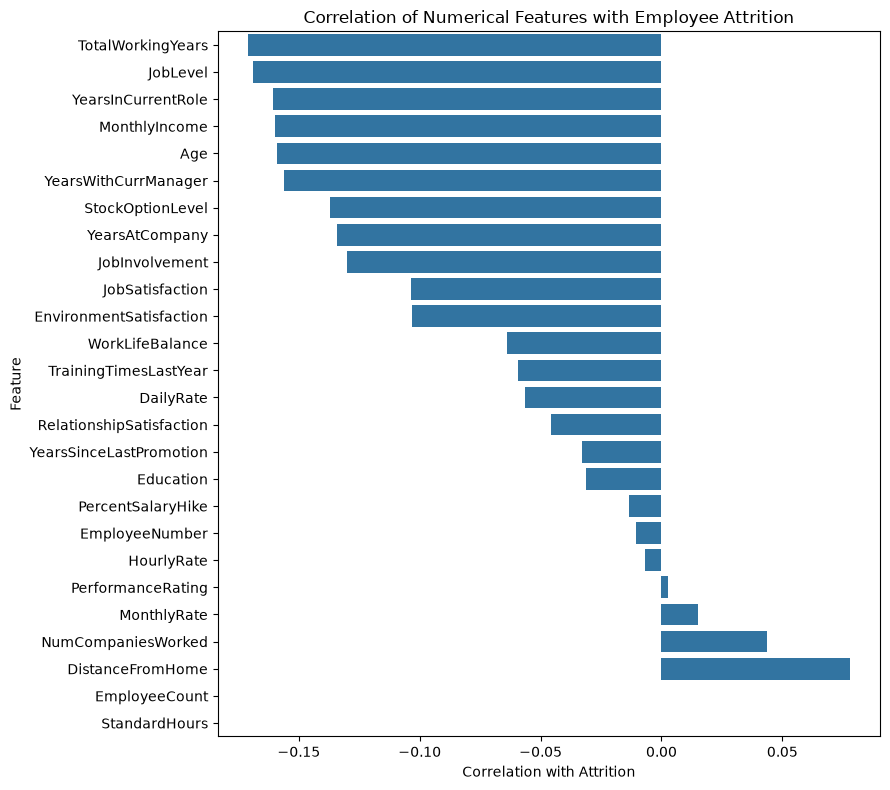

In [94]:
plt.figure(figsize=(9, 8))

sns.barplot(
    x=numeric_corr.values,
    y=numeric_corr.index
)

plt.title("Correlation of Numerical Features with Employee Attrition")
plt.xlabel("Correlation with Attrition")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 5. Data Preprocessing

Machine learning algorithms require the dataset to be transformed into a suitable numerical representation. This stage includes removing irrelevant variables, encoding categorical features, separating the target variable, and preparing the data for model training.

The preprocessing steps are performed carefully to avoid data leakage between the training and testing sets.

### 5.1 Removing Non-Predictive Features

Some columns contain identifiers or information that does not provide meaningful predictive value. These variables are removed before training the models.

In [95]:
# Create a copy of the dataset for machine learning
ml_df = df.copy()

# Remove the employee identifier
ml_df = ml_df.drop(columns=["EmployeeNumber"])

print("Dataset shape after removing the employee identifier:", ml_df.shape)

Dataset shape after removing the employee identifier: (1470, 34)


In [96]:
# Separate features and target variable

X_full = ml_df.drop(columns=["Attrition"])
y = ml_df["Attrition"].map({"No": 0, "Yes": 1})

print("Full feature set:", X_full.shape)
print("Target shape:", y.shape)

Full feature set: (1470, 33)
Target shape: (1470,)


### 5.2 Feature Selection

The dataset initially contains a large number of predictive attributes. Using every available variable is not always necessary, particularly when some variables contribute little additional predictive information.

Feature selection is therefore performed to identify a smaller set of informative predictors. Logistic Regression coefficients are used to rank the original features, after which different feature-set sizes are evaluated using stratified cross-validation.

The final feature set is selected based on the balance between predictive performance and model simplicity.

In [97]:
from sklearn.model_selection import train_test_split

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train_full.shape)
print("Testing set:", X_test_full.shape)

Training set: (1176, 33)
Testing set: (294, 33)


In [98]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Rank original features using Logistic Regression coefficients
# from the training data only.

ranking_categorical = X_train_full.select_dtypes(
    include=["object"]
).columns.tolist()

ranking_numerical = X_train_full.select_dtypes(
    exclude=["object"]
).columns.tolist()

ranking_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            ranking_numerical
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            ranking_categorical
        )
    ]
)

ranking_model = Pipeline(
    steps=[
        ("preprocessor", ranking_preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

ranking_model.fit(X_train_full, y_train)

feature_names = ranking_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = ranking_model.named_steps[
    "classifier"
].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute Importance": np.abs(coefficients)
})

feature_importance["Original Feature"] = (
    feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.split("_")
    .str[0]
)

grouped_importance = (
    feature_importance
    .groupby("Original Feature")["Absolute Importance"]
    .sum()
    .sort_values(ascending=False)
)

grouped_importance

C:\Users\Faraaz\AppData\Local\Temp\ipykernel_45872\2463600509.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  ranking_categorical = X_train_full.select_dtypes(


Original Feature
JobRole                     5.664586
EducationField              2.276643
BusinessTravel              1.861576
OverTime                    1.654970
MaritalStatus               1.038310
Department                  0.835963
TotalWorkingYears           0.620378
JobLevel                    0.601452
YearsSinceLastPromotion     0.502797
NumCompaniesWorked          0.460707
YearsWithCurrManager        0.451943
EnvironmentSatisfaction     0.425731
JobSatisfaction             0.388212
Gender                      0.321563
DistanceFromHome            0.318553
JobInvolvement              0.288305
MonthlyIncome               0.278314
Age                         0.274161
YearsAtCompany              0.249324
RelationshipSatisfaction    0.247866
PercentSalaryHike           0.235097
YearsInCurrentRole          0.232454
WorkLifeBalance             0.223294
DailyRate                   0.222944
StockOptionLevel            0.203452
TrainingTimesLastYear       0.167589
PerformanceRating    

In [99]:
# Evaluate different feature-set sizes using cross-validation
# on the training data only.

ranked_features = grouped_importance.index.tolist()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

feature_set_sizes = [10, 15, 20, 25]

feature_selection_results = []

for k in feature_set_sizes:
    selected_features_temp = ranked_features[:k]

    X_train_selected = X_train_full[selected_features_temp]

    selected_categorical = X_train_selected.select_dtypes(
        include=["object"]
    ).columns.tolist()

    selected_numerical = X_train_selected.select_dtypes(
        exclude=["object"]
    ).columns.tolist()

    selected_preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                selected_numerical
            ),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                selected_categorical
            )
        ]
    )

    selected_model = Pipeline(
        steps=[
            ("preprocessor", selected_preprocessor),
            (
                "classifier",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=1000,
                    random_state=42
                )
            )
        ]
    )

    scores = cross_val_score(
        selected_model,
        X_train_selected,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    feature_selection_results.append({
        "Features Used": k,
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std()
    })

feature_selection_df = pd.DataFrame(
    feature_selection_results
)

feature_selection_df.round(3)

C:\Users\Faraaz\AppData\Local\Temp\ipykernel_45872\3929287863.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  selected_categorical = X_train_selected.select_dtypes(
C:\Users\Faraaz\AppData\Local\Temp\ipykernel_45872\3929287863.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gu

,Features Used,Mean ROC-AUC,Std ROC-AUC
0,10,0.794,0.034
1,15,0.820,0.028
2,20,0.830,0.024
3,25,0.835,0.025


In [100]:
# Select the final 25-feature model

selected_features = ranked_features[:25]

print("Number of selected features:", len(selected_features))
print("\nSelected features:")

for feature in selected_features:
    print("-", feature)

Number of selected features: 25

Selected features:
- JobRole
- EducationField
- BusinessTravel
- OverTime
- MaritalStatus
- Department
- TotalWorkingYears
- JobLevel
- YearsSinceLastPromotion
- NumCompaniesWorked
- YearsWithCurrManager
- EnvironmentSatisfaction
- JobSatisfaction
- Gender
- DistanceFromHome
- JobInvolvement
- MonthlyIncome
- Age
- YearsAtCompany
- RelationshipSatisfaction
- PercentSalaryHike
- YearsInCurrentRole
- WorkLifeBalance
- DailyRate
- StockOptionLevel


In [101]:
print("Training attrition rate:", round(y_train.mean() * 100, 2), "%")
print("Testing attrition rate:", round(y_test.mean() * 100, 2), "%")

Training attrition rate: 16.16 %
Testing attrition rate: 15.99 %


### 5.3 Identifying Feature Types

The dataset contains both numerical and categorical variables. Numerical features can be used directly by many machine learning algorithms, while categorical features must be encoded into numerical representations.

In [102]:
# Create the final 25-feature dataset

X = ml_df[selected_features]

X_train = X_train_full[selected_features]
X_test = X_test_full[selected_features]

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Selected features:", len(selected_features))
print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

Selected features: 25
Categorical features: 7
Numerical features: 18


C:\Users\Faraaz\AppData\Local\Temp\ipykernel_45872\2381134497.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


### 5.4 Feature Preprocessing

Categorical variables are converted into numerical values using one-hot encoding, while numerical variables are standardized.

A `ColumnTransformer` is used so that the same preprocessing steps can be consistently applied to both training and unseen test data.

In [103]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### 5.5 Handling Class Imbalance

The target variable is imbalanced, with fewer employees experiencing attrition than remaining with the organization. This imbalance can cause a model to favor the majority class.

To address this, class weighting is used during model training so that the minority class receives greater importance when classification errors are penalized.


## 6. Machine Learning Models

Multiple classification algorithms are trained and compared to determine which approach provides the most reliable predictions of employee attrition.

The models selected represent different learning approaches, allowing their performance and generalization ability to be evaluated under the same preprocessing and testing conditions.

### 6.1 Logistic Regression

Logistic Regression provides a strong baseline classification model and is particularly useful for understanding how employee characteristics contribute to the probability of attrition.

In [104]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


### 6.2 Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees. It can capture nonlinear relationships and interactions between employee characteristics while also providing useful feature-importance information.

In [105]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


### 6.3 Decision Tree

A Decision Tree is trained to provide an interpretable nonlinear model. It recursively divides the data based on feature values and can capture decision patterns that may not be represented by a linear model.

In [106]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            class_weight="balanced",
            max_depth=6,
            min_samples_split=10,
            random_state=42
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


### 6.4 Support Vector Machine

A Support Vector Machine (SVM) is included as a fourth classification approach. SVM attempts to find an effective decision boundary between employees who leave and those who remain.

Class weighting is used to reduce the tendency of the model to favor the majority class.

In [107]:
from sklearn.svm import SVC

svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]
)

svm_model.fit(X_train, y_train)

print("Support Vector Machine trained successfully.")

c:\University\Employee_Attrition_Prediction\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Support Vector Machine trained successfully.


## 7. Model Evaluation

The trained classification models are evaluated on the held-out test set to compare their predictive performance on previously unseen employee records.

Because employee attrition is an imbalanced classification problem, accuracy alone is not sufficient. Precision, recall, F1-score, and ROC-AUC are considered together to provide a more complete assessment of model performance.

The held-out test set is used only for final performance assessment and is not used to select the final model.

In [108]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "Decision Tree": decision_tree_model,
    "Support Vector Machine": svm_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values("ROC-AUC", ascending=False).round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Support Vector Machine,0.810,0.431,0.596,0.500,0.822
1,Random Forest,0.840,0.500,0.340,0.405,0.794
0,Logistic Regression,0.748,0.345,0.638,0.448,0.791
2,Decision Tree,0.755,0.338,0.553,0.419,0.649


### 7.1 Comparing Model Performance

The evaluation results provide a direct comparison of the four classification models on the held-out test set.

ROC-AUC measures the model's ability to distinguish between employees who leave and those who remain, while precision, recall, and F1-score provide additional information about classification performance.

These results are reported for comparison. Final model selection is performed separately using stratified cross-validation on the training data.

<Figure size 1000x600 with 0 Axes>

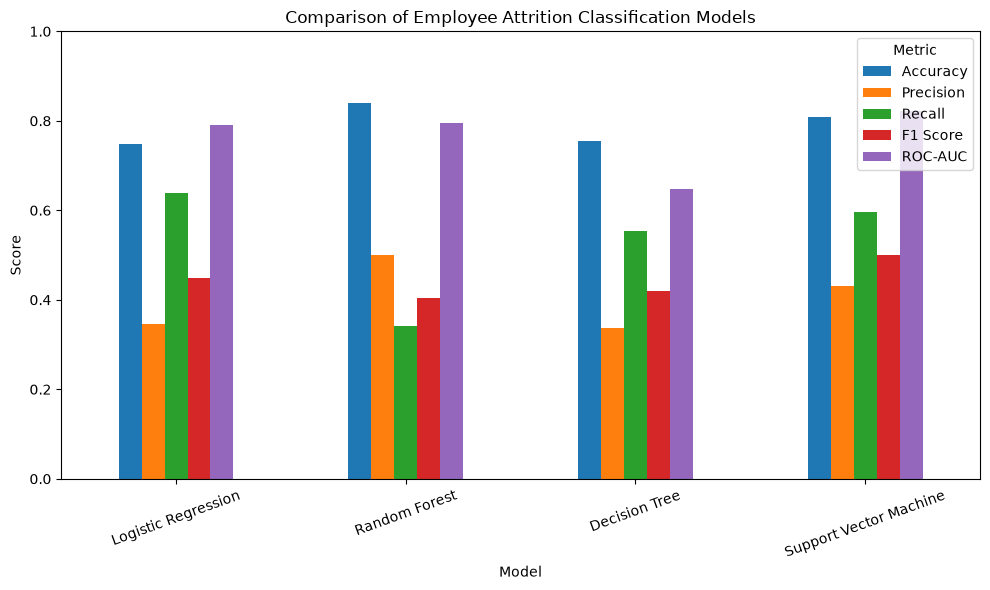

In [109]:
plt.figure(figsize=(10, 6))

comparison_df = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
]

comparison_df.plot(kind="bar", figsize=(10, 6))

plt.title("Comparison of Employee Attrition Classification Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 8. Cross-Validation

A single train-test split provides an estimate of model performance, but its result can depend on how the data was divided.

Stratified cross-validation is therefore used to evaluate the models across multiple training and validation splits. This provides a more robust estimate of their generalization performance.

The held-out test set is not used during cross-validation, ensuring that it remains available for final evaluation.

In [110]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    "Mean ROC-AUC",
    ascending=False
)

cv_results_df.round(3)

,Model,Mean ROC-AUC,Std ROC-AUC
0,Logistic Regression,0.835,0.025
3,Support Vector Machine,0.819,0.038
1,Random Forest,0.812,0.033
2,Decision Tree,0.614,0.018


### 8.1 Final Model Selection

Cross-validation provides a more reliable estimate of model generalization than a single train-test split.

The model with the highest mean ROC-AUC across the five stratified folds is selected as the final model. ROC-AUC is used because it measures the model's ability to distinguish between employees who leave and those who remain across different classification thresholds.

In [111]:
# Select the model with the highest cross-validated ROC-AUC

best_model_name = cv_results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Final selected model:", best_model_name)
print(
    "Mean cross-validated ROC-AUC:",
    round(cv_results_df.iloc[0]["Mean ROC-AUC"], 3)
)

Final selected model: Logistic Regression
Mean cross-validated ROC-AUC: 0.835


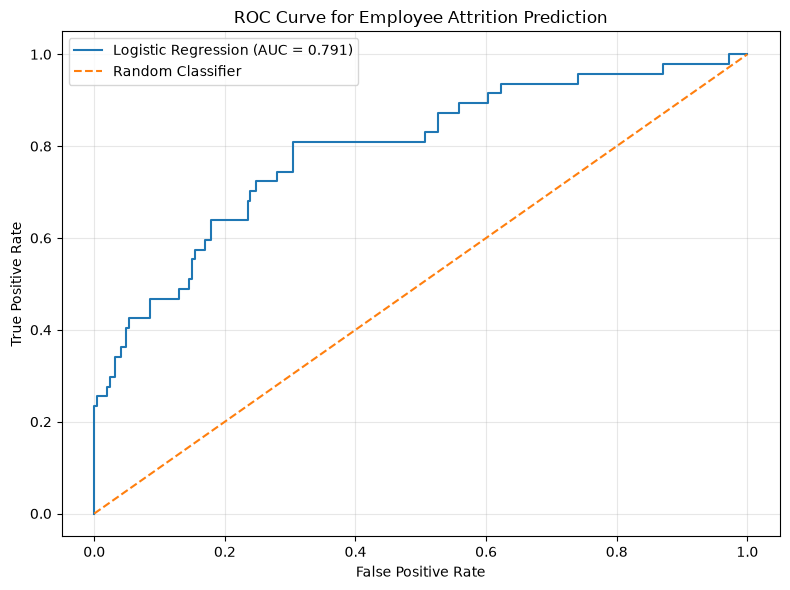

In [112]:
from sklearn.metrics import roc_curve, auc

y_prob_best = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"{best_model_name} (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve for Employee Attrition Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Detailed Evaluation of the Final Model

The final selected model is evaluated in greater detail using a confusion matrix, classification report, and summary performance metrics.

These evaluations are performed on the held-out test set, which was not used during model training, feature selection, cross-validation, or final model selection.


In [113]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_final = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["Stayed", "Left"]
    )
)

Confusion Matrix:
[[190  57]
 [ 17  30]]

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.92      0.77      0.84       247
        Left       0.34      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.83      0.75      0.77       294



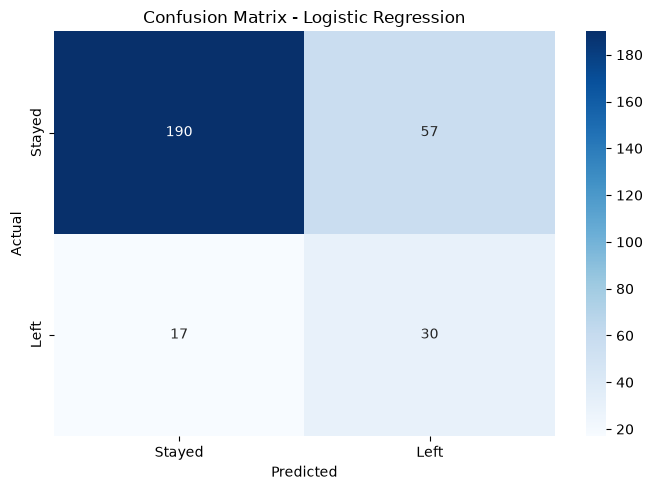

In [114]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### 9.1 Classification Performance

The confusion matrix shows the number of employees correctly and incorrectly classified by the final model.

The classification report provides precision, recall, and F1-score for both classes. These metrics provide more detailed information than accuracy alone, particularly because the dataset contains substantially fewer employees who left than employees who stayed.


In [115]:
# Display final test-set performance metrics

y_prob_final = best_model.predict_proba(X_test)[:, 1]

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred_final),
        precision_score(y_test, y_pred_final),
        recall_score(y_test, y_pred_final),
        f1_score(y_test, y_pred_final),
        roc_auc_score(y_test, y_prob_final)
    ]
})

final_metrics.round(3)


,Metric,Score
0,Accuracy,0.748
1,Precision,0.345
2,Recall,0.638
3,F1 Score,0.448
4,ROC-AUC,0.791


In [116]:
# Extract Logistic Regression coefficients from the final model

logistic_classifier = best_model.named_steps["classifier"]
logistic_preprocessor = best_model.named_steps["preprocessor"]

feature_names = logistic_preprocessor.get_feature_names_out()
coefficients = logistic_classifier.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute Importance": np.abs(coefficients)
}).sort_values(
    "Absolute Importance",
    ascending=False
)

feature_importance.head(15)


,Feature,Coefficient,Absolute Importance
23,cat__JobRole_Research Director,-1.450386,1.450386
20,cat__JobRole_Laboratory Technician,1.188034,1.188034
26,cat__JobRole_Sales Representative,1.111954,1.111954
33,cat__BusinessTravel_Non-Travel,-0.962725,0.962725
36,cat__OverTime_No,-0.901547,0.901547
31,cat__EducationField_Other,-0.779618,0.779618
37,cat__OverTime_Yes,0.772308,0.772308
34,cat__BusinessTravel_Travel_Frequently,0.763496,0.763496
27,cat__EducationField_Human Resources,0.687808,0.687808
18,cat__JobRole_Healthcare Representative,-0.665077,0.665077


In [117]:
# Group encoded categorical features back to their original features

feature_importance_grouped = feature_importance.copy()

feature_importance_grouped["Original Feature"] = (
    feature_importance_grouped["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.split("_")
    .str[0]
)

grouped_importance_final = (
    feature_importance_grouped
    .groupby("Original Feature")["Absolute Importance"]
    .sum()
    .sort_values(ascending=False)
)

grouped_importance_final.to_frame(
    name="Total Absolute Importance"
)


,Total Absolute Importance
Original Feature,
JobRole,5.681014
EducationField,2.237631
BusinessTravel,1.796211
OverTime,1.673855
MaritalStatus,1.010500
Department,0.729830
JobLevel,0.601908
TotalWorkingYears,0.584046
YearsSinceLastPromotion,0.516043


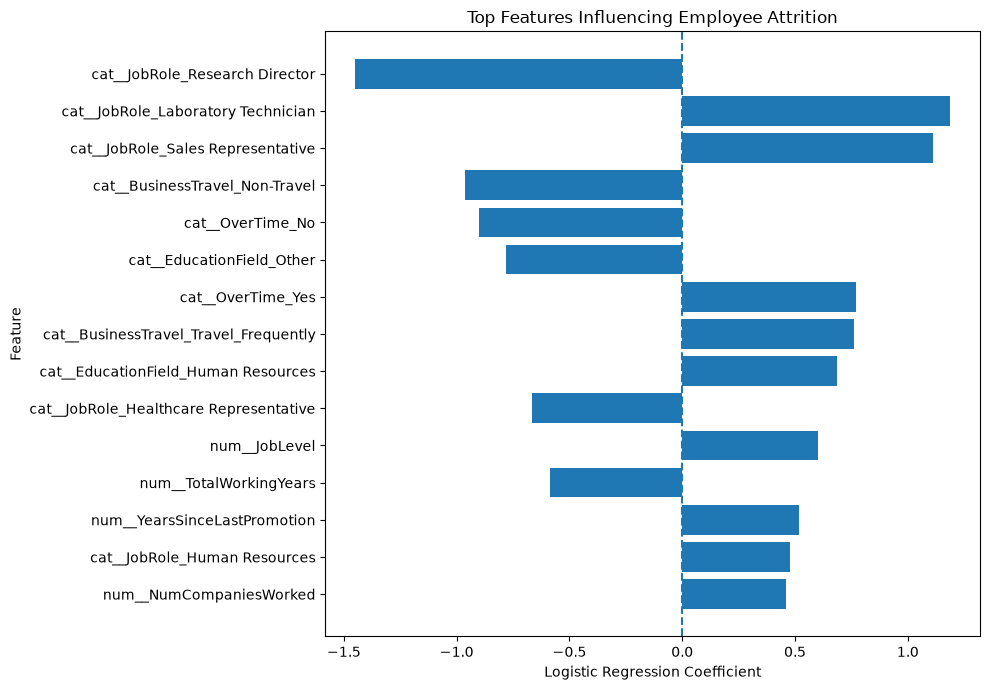

In [118]:
# Visualize the strongest Logistic Regression coefficients

top_features = feature_importance.head(15).sort_values(
    "Absolute Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.title("Top Features Influencing Employee Attrition")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


### 10.1 Interpretation of Important Features

The feature-importance analysis identifies the employee characteristics that contribute most strongly to the Logistic Regression model's predictions.

A positive coefficient indicates an association with a higher predicted probability of attrition, while a negative coefficient indicates an association with a lower predicted probability of attrition, assuming the other variables remain constant.

For categorical variables, the coefficients correspond to the encoded categories used by the model.

These results should be interpreted as predictive associations rather than direct evidence that a particular factor causes an employee to leave.


## 11. Final Model Evaluation

The final selected model is evaluated on the held-out test set to provide the final reported estimate of predictive performance.

The test set was kept separate throughout the model-selection process and was not used during feature selection, cross-validation, or model training.


In [119]:
# Final performance of the selected model on the held-out test set

final_metrics.round(3)


,Metric,Score
0,Accuracy,0.748
1,Precision,0.345
2,Recall,0.638
3,F1 Score,0.448
4,ROC-AUC,0.791


### 11.1 Final Classification Report


In [120]:
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["Stayed", "Left"]
    )
)


              precision    recall  f1-score   support

      Stayed       0.92      0.77      0.84       247
        Left       0.34      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.83      0.75      0.77       294



## 12. Final Model for Deployment

After model selection and final evaluation, the selected Logistic Regression pipeline is retrained using the complete labeled dataset.

Using the complete dataset at this stage allows the final deployment model to learn from all available labeled records while preserving the held-out test-set evaluation as the reported performance estimate.

The trained pipeline can then be saved and reused by the prediction application without repeating the training process.


In [121]:
# Retrain the selected model on the complete dataset for deployment

final_model = models[best_model_name]

final_model.fit(X, y)

print("Final deployment model trained successfully.")
print("Model:", best_model_name)
print("Training records:", len(X))
print("Features used:", len(selected_features))


Final deployment model trained successfully.
Model: Logistic Regression
Training records: 1470
Features used: 25


In [122]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

model_path = "../models/employee_attrition_model.joblib"

joblib.dump(final_model, model_path)

print("Model saved to:", model_path)


Model saved to: ../models/employee_attrition_model.joblib
